# Duplicate CA Cities


#### Step 0: Set-Up
Import the [climakitae](https://github.com/cal-adapt/climakitae) library and other dependencies.

In [143]:
import climakitae as ck

from climakitae.core.data_load import load

import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from climakitae.new_core.data_access.boundaries import Boundaries
import intake
import contextily as cx
import pandas as pd
from shapely.geometry import Point, LineString, Polygon
import matplotlib.cm as cm
import matplotlib.colors as mcolors

#### Step 2: Update new core boundaries file

In [2]:
catalog = intake.open_catalog('boundaries.yaml')
boundaries = Boundaries(catalog)
# Get all boundary options for UI population
boundary_options = boundaries.boundary_dict()

In [3]:
# Access specific boundary data (loaded lazily)
ca_cities = boundaries._ca_cities
ca_counties= boundaries._ca_counties

There 66 duplicate CA city names.

In [19]:
ca_counties["NAME"].duplicated().sum()

np.int64(0)

In [4]:
ca_cities["CDT_NAME_S"].duplicated().sum()

np.int64(66)

All duplicates contain at least one offshore boundary.

In [97]:
duplicate_cities = ca_cities[ca_cities.duplicated(subset=["CENSUS_GEO"], keep=False)]
non_duplicate_cities = ca_cities[~ca_cities["CENSUS_GEO"].duplicated()]

In [121]:
data = []
for name in duplicate_cities["CDT_NAME_S"].unique():
    subset = duplicate_cities[duplicate_cities["CDT_NAME_S"] == name]
    offshore_bool = subset["OFFSHORE"].notna().any()
    data.append({"CDT_NAME_S":name, "offshore_component": offshore_bool})
data_df = pd.DataFrame(data)

In [125]:
perc_offshore_dups = sum(data_df["offshore_component"]) / len(duplicate_cities['CENSUS_GEO'].unique()) * 100
perc_offshore_dups

100.0

Let's map a couple cities.

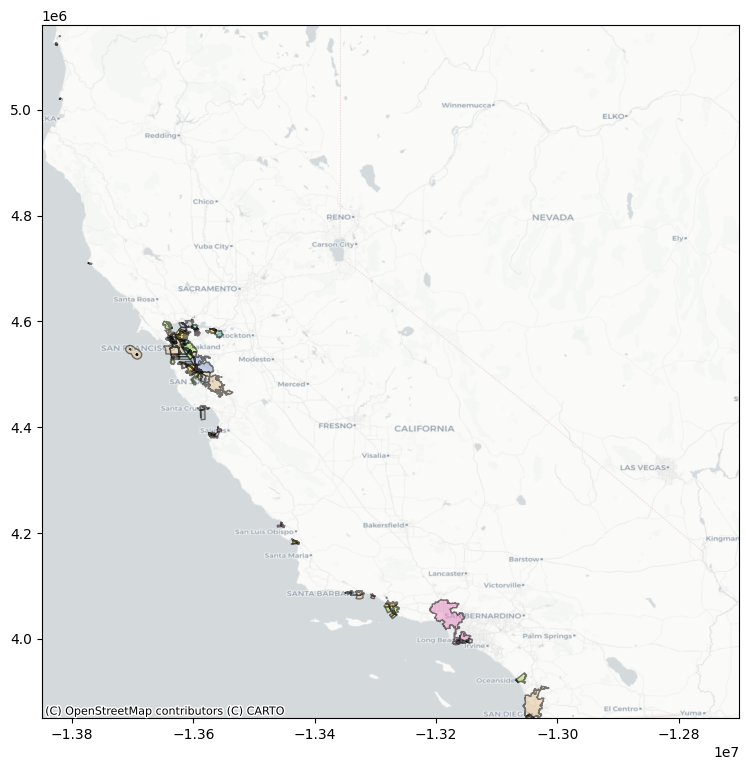

In [156]:
fig, ax = plt.subplots(figsize=(9, 9))

xlim = [-1.385e7, -1.270e7]
ylim = [3.85e6, 5.16e6]
ax.set_ylim(ylim)
ax.set_xlim(xlim)

duplicate_cities = duplicate_cities.to_crs(epsg=3857)

# Build a color map: one color per unique "love" value
categories = duplicate_cities["CENSUS_GEO"].unique()
palette = cm.get_cmap("Set2", len(categories))
color_map = {cat: mcolors.to_hex(palette(i)) for i, cat in enumerate(categories)}

for _, row in duplicate_cities.iterrows():
    geom = row.geometry
    fill_color = color_map[row["CENSUS_GEO"]]

    if geom.geom_type == "Polygon":
        x, y = geom.exterior.xy
        ax.fill(x, y, color=fill_color, alpha=0.5, edgecolor="black")
    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, color=fill_color, alpha=0.5, edgecolor="black")

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

Take a look at Los Angeles.

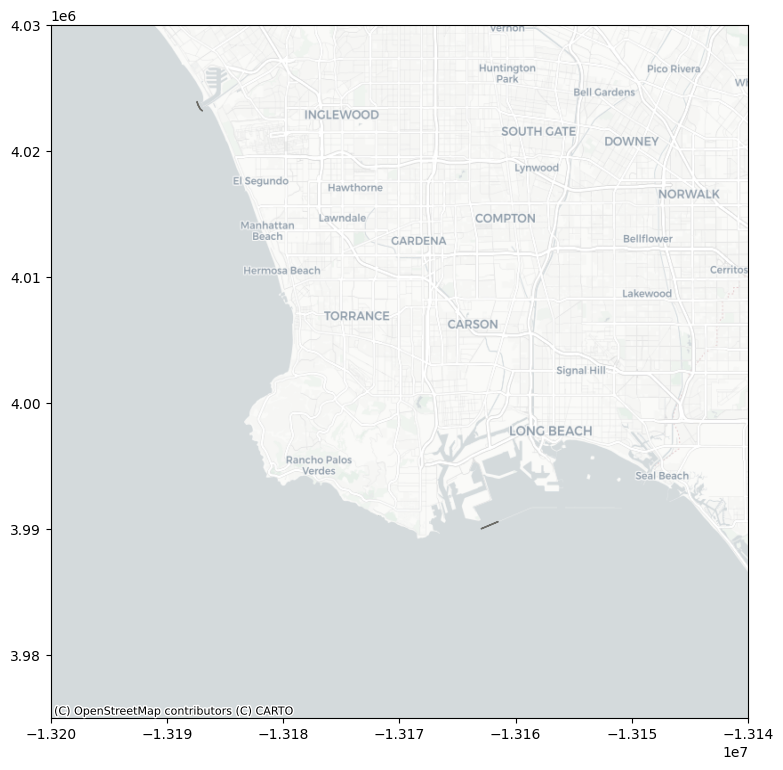

In [186]:
# ZOOMED

city_name = "Los Angeles"

# Figure global settings
fig, ax = plt.subplots(figsize=(9, 9))

# Enforce WECC boundary, all plots regardless of variable selection
xlim = [-1.320e7, -1.314e7]  # lon
ylim = [3.975e6, 4.03e6]  # lat
ax.set_ylim(ylim)
ax.set_xlim(xlim)

# Reproject to match Web Mercator (required for contextily basemaps)
city1 = duplicate_cities[duplicate_cities["CDT_NAME_S"] == city_name][0:1]

for part in city1.geometry:
    if part.geom_type == "Polygon":
        x, y = part.exterior.xy
        ax.fill(x, y, color="orange", alpha=0.5, edgecolor="black")
    elif part.geom_type == "MultiPolygon":
        for poly in part.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, color="orange", alpha=0.5, edgecolor="black")

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

In [187]:
city1

,CDTFA_COPR,CDTFA_CITY,CDTFA_COUN,CENSUS_PLA,CENSUS_GEO,CENSUS_P_1,GNIS_PLACE,GNIS_ID,CDT_CITY_A,CDT_COUNTY,PRIMARY_DO,CENSUS_POP,CDT_NAME_S,OFFSHORE,AREA_SQMI,GlobalID,geometry
508,19201,Los Angeles,Los Angeles County,Los Angeles,0644000,City,City of Los Angeles,2410877,LANG,LAC,None,0,Los Angeles,ocean,0.011465,f118fa2c-4e62-4848-badb-75383ec86e6a,"MULTIPOLYGON (((-13186947.066 4023196.807, -13..."


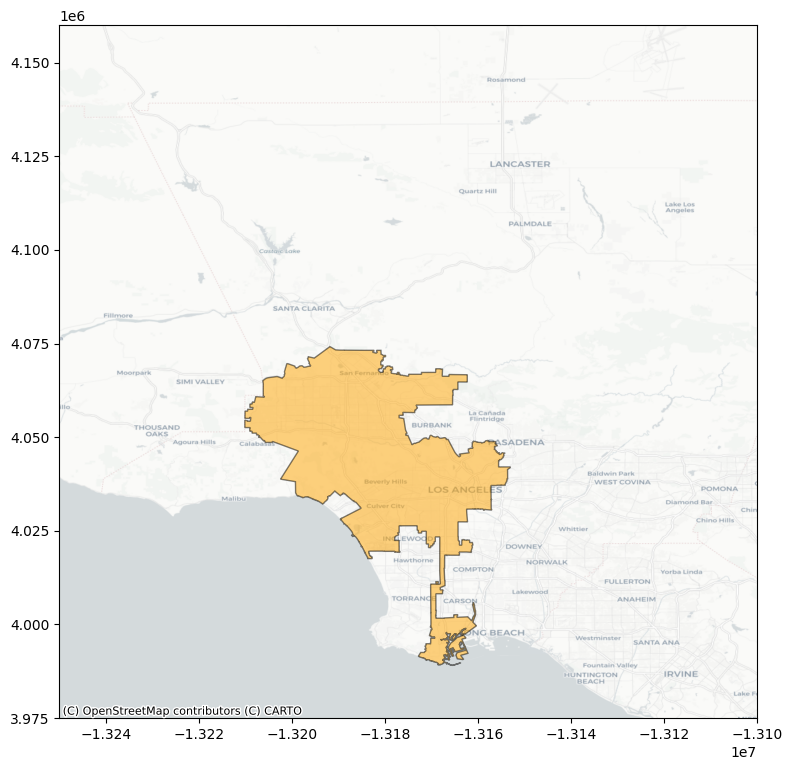

In [189]:
city_name = "Los Angeles"

# Figure global settings
fig, ax = plt.subplots(figsize=(9, 9))

# Enforce WECC boundary, all plots regardless of variable selection
xlim = [-1.325e7, -1.31e7]  # lon
ylim = [3.975e6, 4.16e6]  # lat
ax.set_ylim(ylim)
ax.set_xlim(xlim)

# Reproject to match Web Mercator (required for contextily basemaps)
city2 = duplicate_cities[duplicate_cities["CDT_NAME_S"] == city_name][1:2]

for part in city2.geometry:
    if part.geom_type == "Polygon":
        x, y = part.exterior.xy
        ax.fill(x, y, color="orange", alpha=0.5, edgecolor="black")
    elif part.geom_type == "MultiPolygon":
        for poly in part.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, color="orange", alpha=0.5, edgecolor="black")

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

In [190]:
city2

,CDTFA_COPR,CDTFA_CITY,CDTFA_COUN,CENSUS_PLA,CENSUS_GEO,CENSUS_P_1,GNIS_PLACE,GNIS_ID,CDT_CITY_A,CDT_COUNTY,PRIMARY_DO,CENSUS_POP,CDT_NAME_S,OFFSHORE,AREA_SQMI,GlobalID,geometry
239,19201,Los Angeles,Los Angeles County,Los Angeles,0644000,City,City of Los Angeles,2410877,LANG,LAC,None,0,Los Angeles,None,473.247396,3306fcab-7997-4918-90f1-c619fea6596f,"MULTIPOLYGON (((-13163008.189 3997116.5, -1316..."
